# Complex Systems

## Module 3: Properties of Complex Systems including Self-Organisation and Emergence


### It is to answer this question:
####     - What about the high dimensionality of EMA dataset? Are there key variables that describe the system dynamics? Or do they capture distinct systems?


In [ ]:
# @title Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# @title Upload EMS File
df = pd.read_csv('/content/ESMdata.csv', index_col = 'Unnamed: 0')

In [ ]:
df.columns

Index(['date', 'phase', 'concentrat', 'dayno', 'beepno', 'beeptime',
       'resptime_s', 'resptime_e', 'resp_abort', 'mood_relaxed', 'mood_down',
       'mood_irritat', 'mood_satisfi', 'mood_lonely', 'mood_anxious',
       'mood_enthus', 'mood_suspic', 'mood_cheerf', 'mood_guilty',
       'mood_doubt', 'mood_strong', 'pat_restl', 'pat_agitate', 'pat_worry',
       'pat_concent', 'se_selflike', 'se_ashamed', 'se_selfdoub', 'se_handle',
       'soc_who1', 'soc_enjoy_alone', 'soc_prefcomp', 'soc_who2', 'soc_who3',
       'soc_belong', 'soc_pleasant', 'soc_prefalone', 'soc_together',
       'phy_hungry', 'phy_tired', 'phy_pain', 'phy_dizzy', 'phy_drymouth',
       'phy_nauseous', 'phy_headache', 'phy_sleepy', 'act_what1', 'act_what2',
       'act_difficul', 'act_well', 'act_enjoy', 'phy_physact', 'event_pleas',
       'event_import', 'event_cause', 'event_concern', 'event_freq',
       'event_pertain', 'event_disturb', 'evn_ordinary', 'evn_niceday',
       'evn_inflmood', 'evn_pager', 'ev

In [ ]:
# @title Date to datetime
df['date'] = pd.to_datetime(df['date'])


/tmp/ipython-input-584440916.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


In [ ]:
df.dtypes

,0
date,datetime64[ns]
phase,int64
concentrat,int64
dayno,int64
beepno,int64
...,...
SCL.90.R.32,float64
SCL.90.R.54,float64
SCL.90.R.71,float64
SCL.90.R.79,float64


In [ ]:
# @title Select only numeric columns for analysis
data_numeric = df.select_dtypes(include='number')
print(data_numeric.head())

   phase  concentrat  dayno  beepno  resp_abort  mood_relaxed  mood_down  \
1      1         150    226       1         0.0             5       -1.0   
2      1         150    227       5         0.0             4        0.0   
3      1         150    227       6         0.0             4        0.0   
4      1         150    227       8         0.0             4        0.0   
5      1         150    227       9         0.0             4        0.0   

   mood_irritat  mood_satisfi  mood_lonely  ...  SCL.90.R.29  SCL.90.R.26  \
1           1.0           5.0         -1.0  ...          1.0          1.0   
2           3.0           3.0          0.0  ...          NaN          NaN   
3           2.0           3.0          0.0  ...          NaN          NaN   
4           1.0           4.0          0.0  ...          NaN          NaN   
5           2.0           4.0          0.0  ...          NaN          NaN   

   SCL.90.R.15  SCL.90.R.30  SCL.90.R.31  SCL.90.R.32  SCL.90.R.54  \
1         

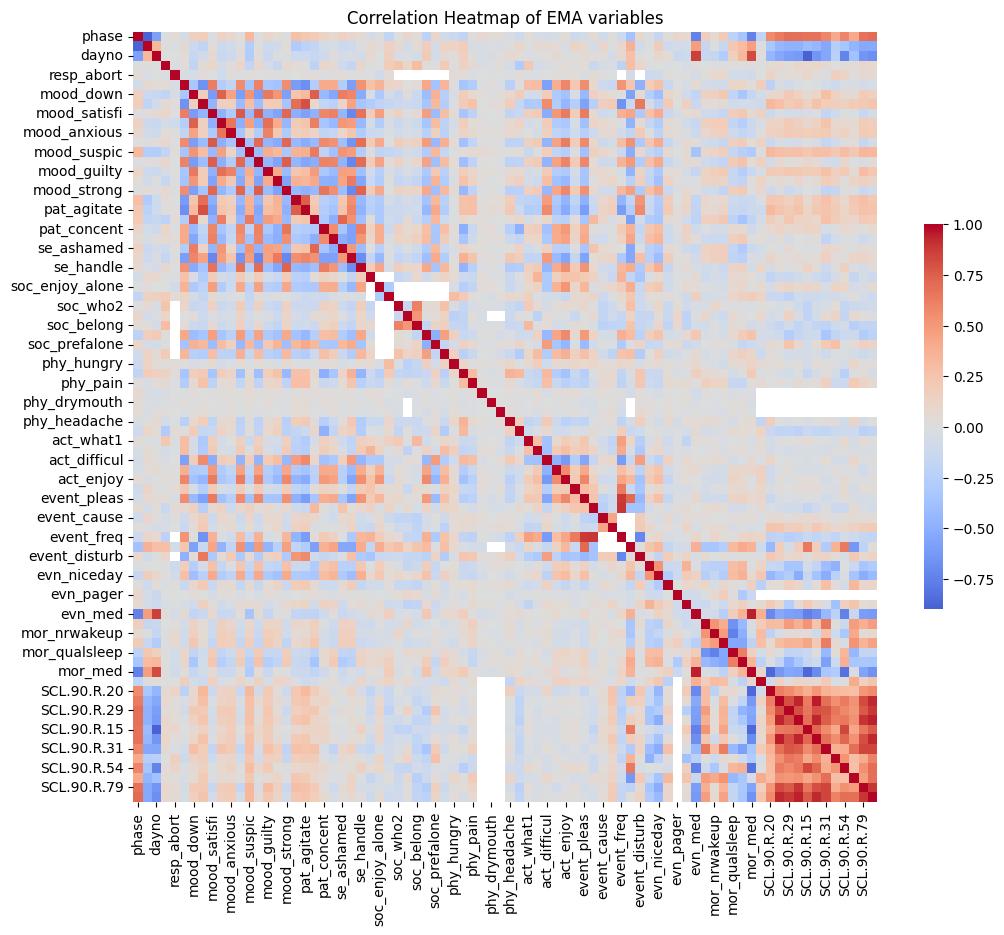

In [ ]:
# @title SNS heatmap for correlations
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, cbar_kws={'shrink':0.5})
plt.title("Correlation Heatmap of EMA variables")
plt.show()


So based on this graph, we can safely say that we just delete all the variables that has no to little input, we tweak as well depending how many variables stays.

In [ ]:
# @title Removing variable that doesn't exists

# deleting 'SCL.90.R.5'
df = df.drop('SCL.90.R.5', axis=1)

In [ ]:
# @title checking the number values in the corr matrix
for var, num in corr.items():
  print(var, num.mean())

phase 0.0722885759727029
concentrat -0.05378507768637471
dayno -0.06555758453255199
beepno 0.029018166107442032
resp_abort 0.01683061944902374
mood_relaxed 0.022036847175489326
mood_down 0.00978655581422797
mood_irritat 0.013834223959537451
mood_satisfi 0.028826002222915502
mood_lonely 0.02050062292927255
mood_anxious 0.02811292612767205
mood_enthus 0.03101157190132368
mood_suspic 0.037800781081045794
mood_cheerf 0.04100195114247087
mood_guilty 0.031067167142487535
mood_doubt -0.0005366898763919673
mood_strong 0.028314062076519632
pat_restl 0.01689205227948829
pat_agitate 0.013705774109342025
pat_worry 0.01922392056722867
pat_concent 0.04561215865321602
se_selflike 0.024868706588286476
se_ashamed 0.0004269014470023397
se_selfdoub -0.012206844124886462
se_handle 0.035664113973894
soc_who1 0.0018955746300785175
soc_enjoy_alone 0.040007639661623594
soc_prefcomp 0.005340275718842452
soc_who2 0.0005244050455504219
soc_who3 -0.006706224081479233
soc_belong -0.018945318293547803
soc_pleasant 